# Replay & Analytics Dashboard

Historical replay simulation and institutional-grade performance analytics.

> **Prerequisite:** Run `main_mean_reversion.ipynb` first to generate bridge data.


In [1]:
# ============================================================================
# LOAD BRIDGE DATA — from core backtest notebook
# ============================================================================
import gc
gc.collect()

%load_ext autoreload
%autoreload 2

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Resolve project root
project_root = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

from strategy_config import ConfigLoader
from backtest.engine import BacktestEngine, BacktestConfig, calculate_rolling_sharpe, calculate_underwater_curve

# Load bridge data
_bridge_path = project_root / 'data' / 'snapshots' / 'notebook_bridge' / 'core_results.pkl'
with open(_bridge_path, 'rb') as f:
    _bridge = pickle.load(f)

results = _bridge['results']
bt_config = _bridge['bt_config']
config = ConfigLoader(Path(_bridge['config_path']))
price_df = _bridge['price_df']
signal_df = _bridge['signal_df']
volume_df = _bridge['volume_df']
zscore_df = _bridge['zscore_df']
analysis_df = _bridge['analysis_df']
all_data = _bridge['all_data']

del _bridge
gc.collect()

# ── Build open_price_df from all_data (OHLCV per symbol) ──
# Used by Scenario 2 (T+1 Open) to fill entries at next-day open prices
open_price_df = pd.DataFrame(index=price_df.index, columns=price_df.columns, dtype=float)
for sym in price_df.columns:
    if sym in all_data and all_data[sym] is not None and 'open' in all_data[sym].columns:
        open_price_df[sym] = all_data[sym]['open'].reindex(price_df.index)

# ── Shifted signals for T+1 scenarios ──
# shift(1): signal from day T appears on day T+1
# → on day T+1, we execute using yesterday's signal
signal_df_t1 = signal_df.shift(1)
zscore_df_t1 = zscore_df.shift(1)

# ── Replay window (last 2 years) ──
replay_end = signal_df.index.max()
replay_start = replay_end - pd.DateOffset(years=2)

# ── Scenario results container ──
scenario_results = {}

print('✓ Bridge data loaded successfully')
print(f'  Symbols: {len(signal_df.columns)}')
print(f'  Date range: {signal_df.index.min()} → {signal_df.index.max()}')
print(f'  Backtest trades: {results.total_trades}')
print(f'  Replay window: {replay_start.strftime("%Y-%m-%d")} → {replay_end.strftime("%Y-%m-%d")}')
print(f'  Trading days in window: {((signal_df.index >= replay_start) & (signal_df.index <= replay_end)).sum()}')
print(f'\n✓ T+1 data prepared:')
print(f'  open_price_df: {open_price_df.shape} ({open_price_df.notna().sum().sum():,} values)')
print(f'  signal_df_t1:  {signal_df_t1.shape} (shifted by 1 day)')
print(f'  zscore_df_t1:  {zscore_df_t1.shape} (shifted by 1 day)')


✓ Bridge data loaded successfully
  Symbols: 216
  Date range: 2006-02-14 00:00:00 → 2026-02-13 00:00:00
  Backtest trades: 14820
  Replay window: 2024-02-13 → 2026-02-13
  Trading days in window: 503

✓ T+1 data prepared:
  open_price_df: (5032, 294) (1,212,376 values)
  signal_df_t1:  (5032, 216) (shifted by 1 day)
  zscore_df_t1:  (5032, 216) (shifted by 1 day)


## Phase 9: Animated Historical Replay — T+1 Execution Bias Analysis

Replays the full trading pipeline day-by-day with **live-updating charts** and **scrolling execution logs**, running **3 scenarios** to quantify T+1 execution bias:

| Scenario | Signal Source | Fill Price | What It Tests |
|----------|--------------|------------|---------------|
| **1. T+0 Close** | Day T close | Day T close | Current production settings (baseline) |
| **2. T+1 Open** | Day T close | Day T+1 open | Realistic next-day execution at market open |
| **3. T+1 Close** | Day T close | Day T+1 close | Pure 1-day signal delay (worst case) |

**Why this matters:** Our VM executes at 3:55 PM ET (5 min before close), so real-world performance falls between Scenario 1 and Scenario 2. If Sharpe remains strong across all 3, the strategy's alpha is robust and not explained by look-ahead bias.

> **Each scenario runs the full AnimatedReplay with event logs.** Run cells sequentially — each takes ~30-60s in fast mode.


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# SCENARIO 1: T+0 Close Entry (Current Production Settings)
# ═══════════════════════════════════════════════════════════════════════════
# Signal fires at day T close → Entry fills at day T close (same bar)
# This is our baseline — matches the current VM behavior at 3:55 PM ET.

if 'replay_t0' in dir() and hasattr(replay_t0, 'cleanup'):
    replay_t0.cleanup()
    del replay_t0
import gc; gc.collect()

from execution.animated_replay import AnimatedReplay

print("=" * 70)
print("  SCENARIO 1: T+0 Close Entry (Current Settings)")
print("=" * 70)
print(f"  Replay window: {replay_start.strftime('%Y-%m-%d')} → {replay_end.strftime('%Y-%m-%d')}")
print(f"  Fill price: Same day close | Signal lag: 0 days")
print(f"  Capital: ${bt_config.initial_capital:,.0f}")
print(f"  Entry threshold: {bt_config.entry_threshold}")
print(f"  Stop loss: {bt_config.stop_loss_pct:.0%}" if bt_config.stop_loss_pct else "  Stop loss: Disabled")
print()

replay_t0 = AnimatedReplay(
    config=config,
    bt_config=bt_config,
    price_df=price_df,        # ← Close prices for fills
    signal_df=signal_df,      # ← Original signals (no shift)
    volume_df=volume_df,
    zscore_df=zscore_df,      # ← Original exit signals (no shift)
    analysis_df=analysis_df,
    initial_capital=bt_config.initial_capital,
)

replay_results_t0, replay_sim_t0 = replay_t0.run(
    start_date=replay_start.strftime('%Y-%m-%d'),
    end_date=replay_end.strftime('%Y-%m-%d'),
    speed_multiplier=1.0,
    fast_mode=True,
)

# Store for comparison
scenario_results['T+0 Close'] = replay_results_t0

# Backward compatibility for analytics cells below
replay_results = replay_results_t0
replay_sim = replay_sim_t0

print(f"\n✓ Scenario 1 complete — Sharpe: {replay_results_t0['sharpe_ratio']:.2f} | "
      f"Return: {replay_results_t0['total_return_pct']:.1f}% | "
      f"Trades: {replay_results_t0['total_trades']}")


  SCENARIO 1: T+0 Close Entry (Current Settings)
  Replay window: 2024-02-13 → 2026-02-13
  Fill price: Same day close | Signal lag: 0 days
  Capital: $10,000
  Entry threshold: 1.5
  Stop loss: 12%




✓ Scenario 1 complete — Sharpe: 6.99 | Return: 1608.5% | Trades: 1564


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# SCENARIO 2: T+1 Market Open Entry
# ═══════════════════════════════════════════════════════════════════════════
# Signal fires at day T close → Entry fills at day T+1 market open.
# Tests: How much alpha erodes when you can't trade until next morning?
# This is the most realistic scenario for strategies that compute signals
# after market close and execute at next-day open.

if 'replay_t1_open' in dir() and hasattr(replay_t1_open, 'cleanup'):
    replay_t1_open.cleanup()
    del replay_t1_open
import gc; gc.collect()

from execution.animated_replay import AnimatedReplay

print("=" * 70)
print("  SCENARIO 2: T+1 Market Open Entry")
print("=" * 70)
print(f"  Replay window: {replay_start.strftime('%Y-%m-%d')} → {replay_end.strftime('%Y-%m-%d')}")
print(f"  Fill price: Next day OPEN | Signal lag: 1 day")
print(f"  Capital: ${bt_config.initial_capital:,.0f}")
print()

replay_t1_open = AnimatedReplay(
    config=config,
    bt_config=bt_config,
    price_df=open_price_df,       # ← Open prices for fills
    signal_df=signal_df_t1,       # ← Signals shifted by 1 day
    volume_df=volume_df,
    zscore_df=zscore_df_t1,       # ← Exit signals also shifted
    analysis_df=analysis_df,
    initial_capital=bt_config.initial_capital,
)

replay_results_t1_open, replay_sim_t1_open = replay_t1_open.run(
    start_date=replay_start.strftime('%Y-%m-%d'),
    end_date=replay_end.strftime('%Y-%m-%d'),
    speed_multiplier=1.0,
    fast_mode=True,
)

# Store for comparison
scenario_results['T+1 Open'] = replay_results_t1_open

print(f"\n✓ Scenario 2 complete — Sharpe: {replay_results_t1_open['sharpe_ratio']:.2f} | "
      f"Return: {replay_results_t1_open['total_return_pct']:.1f}% | "
      f"Trades: {replay_results_t1_open['total_trades']}")


  SCENARIO 2: T+1 Market Open Entry
  Replay window: 2024-02-13 → 2026-02-13
  Fill price: Next day OPEN | Signal lag: 1 day
  Capital: $10,000




✓ Scenario 2 complete — Sharpe: 6.00 | Return: 1124.5% | Trades: 1552


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# SCENARIO 3: T+1 Market Close Entry
# ═══════════════════════════════════════════════════════════════════════════
# Signal fires at day T close → Entry fills at day T+1 close.
# Tests: Pure 1-day signal delay (worst case T+1 scenario).
# If the strategy survives this, the alpha is genuinely persistent
# and NOT explained by look-ahead bias.

if 'replay_t1_close' in dir() and hasattr(replay_t1_close, 'cleanup'):
    replay_t1_close.cleanup()
    del replay_t1_close
import gc; gc.collect()

from execution.animated_replay import AnimatedReplay

print("=" * 70)
print("  SCENARIO 3: T+1 Market Close Entry")
print("=" * 70)
print(f"  Replay window: {replay_start.strftime('%Y-%m-%d')} → {replay_end.strftime('%Y-%m-%d')}")
print(f"  Fill price: Next day CLOSE | Signal lag: 1 day")
print(f"  Capital: ${bt_config.initial_capital:,.0f}")
print()

replay_t1_close = AnimatedReplay(
    config=config,
    bt_config=bt_config,
    price_df=price_df,            # ← Close prices for fills (same as T+0)
    signal_df=signal_df_t1,       # ← Signals shifted by 1 day
    volume_df=volume_df,
    zscore_df=zscore_df_t1,       # ← Exit signals also shifted
    analysis_df=analysis_df,
    initial_capital=bt_config.initial_capital,
)

replay_results_t1_close, replay_sim_t1_close = replay_t1_close.run(
    start_date=replay_start.strftime('%Y-%m-%d'),
    end_date=replay_end.strftime('%Y-%m-%d'),
    speed_multiplier=1.0,
    fast_mode=True,
)

# Store for comparison
scenario_results['T+1 Close'] = replay_results_t1_close

print(f"\n✓ Scenario 3 complete — Sharpe: {replay_results_t1_close['sharpe_ratio']:.2f} | "
      f"Return: {replay_results_t1_close['total_return_pct']:.1f}% | "
      f"Trades: {replay_results_t1_close['total_trades']}")


  SCENARIO 3: T+1 Market Close Entry
  Replay window: 2024-02-13 → 2026-02-13
  Fill price: Next day CLOSE | Signal lag: 1 day
  Capital: $10,000




✓ Scenario 3 complete — Sharpe: 3.48 | Return: 274.8% | Trades: 1555


## T+1 Execution Bias — 3-Way Comparison

Side-by-side metrics table + overlaid equity curves across all 3 execution timing scenarios. Quantifies how much alpha erodes under realistic T+1 execution constraints.


In [5]:
# ============================================================================
# 3-WAY SCENARIO COMPARISON: T+0 Close vs T+1 Open vs T+1 Close
# ============================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# ── Color scheme ──
SCENARIO_COLORS = {
    'T+0 Close': '#667eea',    # Blue (baseline)
    'T+1 Open':  '#f0883e',    # Orange
    'T+1 Close': '#da3633',    # Red
}
SCENARIO_LABELS = {
    'T+0 Close': 'T+0 Close (Current)',
    'T+1 Open':  'T+1 Open (Next Day Open)',
    'T+1 Close': 'T+1 Close (Next Day Close)',
}

def _cagr(eq_curve):
    """Compute CAGR from equity curve."""
    if eq_curve is None or len(eq_curve) < 2:
        return 0.0
    years = (eq_curve.index[-1] - eq_curve.index[0]).days / 365.25
    if years <= 0:
        return 0.0
    return ((eq_curve.iloc[-1] / eq_curve.iloc[0]) ** (1 / years) - 1) * 100

assert len(scenario_results) == 3, (
    f"Expected 3 scenarios, got {len(scenario_results)}. "
    "Run all 3 scenario cells above first."
)

baseline  = scenario_results['T+0 Close']
t1_open   = scenario_results['T+1 Open']
t1_close  = scenario_results['T+1 Close']

# ════════════════════════════════════════════════════════════════════════
# METRICS TABLE
# ════════════════════════════════════════════════════════════════════════
print("=" * 100)
print("  T+1 EXECUTION BIAS ANALYSIS — 3-Way Scenario Comparison")
print("=" * 100)

header = f"\n  {'Metric':<22s} {'T+0 Close':>14s} {'T+1 Open':>14s} {'T+1 Close':>14s} {'Δ T+1 Open':>12s} {'Δ T+1 Close':>12s}"
print(header)
print("  " + "─" * 96)

rows = [
    ('Total Return (%)',  'total_return_pct',  '{:>13.1f}%'),
    ('Sharpe Ratio',      'sharpe_ratio',      '{:>14.2f}'),
    ('Max Drawdown (%)',  'max_drawdown_pct',  '{:>13.1f}%'),
    ('Win Rate (%)',      'win_rate',          '{:>13.1f}%'),
    ('Total Trades',      'total_trades',      '{:>14d}'),
    ('Final Equity ($)',  'final_equity',      '${:>12,.0f}'),
]

for label, key, fmt in rows:
    v0 = baseline[key]
    v1 = t1_open[key]
    v2 = t1_close[key]
    d1 = v1 - v0
    d2 = v2 - v0

    if isinstance(v0, int):
        line = f"  {label:<22s} {v0:>14d} {v1:>14d} {v2:>14d} {d1:>+12d} {d2:>+12d}"
    elif 'Equity' in label:
        line = f"  {label:<22s} ${v0:>12,.0f} ${v1:>12,.0f} ${v2:>12,.0f} ${d1:>+10,.0f} ${d2:>+10,.0f}"
    elif '%' in fmt:
        line = f"  {label:<22s} {v0:>13.1f}% {v1:>13.1f}% {v2:>13.1f}% {d1:>+11.1f}% {d2:>+11.1f}%"
    else:
        line = f"  {label:<22s} {v0:>14.2f} {v1:>14.2f} {v2:>14.2f} {d1:>+12.2f} {d2:>+12.2f}"
    print(line)

# CAGR row
cagr_0 = _cagr(baseline.get('equity_curve'))
cagr_1 = _cagr(t1_open.get('equity_curve'))
cagr_2 = _cagr(t1_close.get('equity_curve'))
print(f"  {'CAGR (%)':<22s} {cagr_0:>13.1f}% {cagr_1:>13.1f}% {cagr_2:>13.1f}% {cagr_1 - cagr_0:>+11.1f}% {cagr_2 - cagr_0:>+11.1f}%")

# ════════════════════════════════════════════════════════════════════════
# BIAS ASSESSMENT
# ════════════════════════════════════════════════════════════════════════
sharpe_0 = baseline['sharpe_ratio']
sharpe_1 = t1_open['sharpe_ratio']
sharpe_2 = t1_close['sharpe_ratio']

decay_open  = (1 - sharpe_1 / sharpe_0) * 100 if sharpe_0 != 0 else 0
decay_close = (1 - sharpe_2 / sharpe_0) * 100 if sharpe_0 != 0 else 0

print(f"\n  {'─' * 96}")
print(f"  BIAS ASSESSMENT")
print(f"  {'─' * 96}")
print(f"  Sharpe decay (T+0 → T+1 Open):  {decay_open:+.1f}%  ({sharpe_0:.2f} → {sharpe_1:.2f})")
print(f"  Sharpe decay (T+0 → T+1 Close): {decay_close:+.1f}%  ({sharpe_0:.2f} → {sharpe_2:.2f})")

if sharpe_1 > 2.0 and sharpe_2 > 1.5:
    verdict = "✅ STRONG — Strategy survives T+1 execution with solid alpha"
elif sharpe_1 > 1.0:
    verdict = "⚠️  MODERATE — Meaningful alpha erosion but strategy remains viable"
elif sharpe_1 > 0:
    verdict = "🟡 MARGINAL — Strategy barely survives T+1 delay"
else:
    verdict = "❌ FAIL — Alpha fully explained by T+0 look-ahead bias"
print(f"\n  Verdict: {verdict}")

print(f"\n  📌 VM Context: Executes at 3:55 PM ET (5 min before close)")
print(f"     → Real-world fill is between T+0 Close and T+1 Open")
print(f"     → Expected Sharpe range: {sharpe_1:.2f} (T+1 Open) to {sharpe_0:.2f} (T+0 Close)")

# ════════════════════════════════════════════════════════════════════════
# 3-PANEL VISUALIZATION
# ════════════════════════════════════════════════════════════════════════
fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True,
    row_heights=[0.50, 0.25, 0.25],
    vertical_spacing=0.06,
    subplot_titles=[
        'Equity Curves — T+0 vs T+1 Execution Timing (base = 100)',
        'Drawdown Comparison',
        'Cumulative Trade P&L',
    ],
)

# Panel 1 — Normalized equity curves
for name in ['T+0 Close', 'T+1 Open', 'T+1 Close']:
    eq = scenario_results[name].get('equity_curve')
    if eq is not None and len(eq) > 0:
        eq_norm = eq / eq.iloc[0] * 100
        fig.add_trace(go.Scatter(
            x=eq_norm.index, y=eq_norm.values,
            mode='lines', name=SCENARIO_LABELS[name],
            line=dict(color=SCENARIO_COLORS[name], width=2),
        ), row=1, col=1)

# Panel 2 — Drawdowns
for name in ['T+0 Close', 'T+1 Open', 'T+1 Close']:
    eq = scenario_results[name].get('equity_curve')
    if eq is not None and len(eq) > 0:
        peak = eq.cummax()
        dd = (eq - peak) / peak * 100
        color = SCENARIO_COLORS[name]
        # Parse hex to rgba for fill
        r, g, b = int(color[1:3], 16), int(color[3:5], 16), int(color[5:7], 16)
        fig.add_trace(go.Scatter(
            x=dd.index, y=dd.values,
            mode='lines', name=f'{name} DD',
            line=dict(color=color, width=1.5),
            fill='tozeroy', fillcolor=f'rgba({r},{g},{b},0.1)',
            showlegend=False,
        ), row=2, col=1)

# Panel 3 — Cumulative trade P&L
for name in ['T+0 Close', 'T+1 Open', 'T+1 Close']:
    trades_df = scenario_results[name].get('trades_df')
    if trades_df is not None and len(trades_df) > 0:
        sorted_trades = trades_df.sort_values('exit_date')
        cum_pnl = sorted_trades['pnl'].cumsum()
        fig.add_trace(go.Scatter(
            x=sorted_trades['exit_date'], y=cum_pnl.values,
            mode='lines', name=f'{name} Cum P&L',
            line=dict(color=SCENARIO_COLORS[name], width=1.5),
            showlegend=False,
        ), row=3, col=1)

fig.update_layout(
    height=950, autosize=True,
    template='plotly_dark',
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    legend=dict(orientation='h', x=0, y=1.05),
    margin=dict(l=60, r=30, t=40, b=30),
)
fig.update_yaxes(title_text='Normalized Equity', row=1, col=1)
fig.update_yaxes(title_text='Drawdown (%)', row=2, col=1)
fig.update_yaxes(title_text='Cumulative P&L ($)', row=3, col=1)

fig.show()
plt.close('all')

# ── Export comparison to CSV ──
comparison_df = pd.DataFrame({
    'Metric': ['Total Return (%)', 'Sharpe Ratio', 'Max Drawdown (%)', 'Win Rate (%)',
               'Total Trades', 'Final Equity ($)', 'CAGR (%)'],
    'T+0 Close': [baseline['total_return_pct'], sharpe_0, baseline['max_drawdown_pct'],
                  baseline['win_rate'], baseline['total_trades'], baseline['final_equity'], cagr_0],
    'T+1 Open':  [t1_open['total_return_pct'], sharpe_1, t1_open['max_drawdown_pct'],
                  t1_open['win_rate'], t1_open['total_trades'], t1_open['final_equity'], cagr_1],
    'T+1 Close': [t1_close['total_return_pct'], sharpe_2, t1_close['max_drawdown_pct'],
                  t1_close['win_rate'], t1_close['total_trades'], t1_close['final_equity'], cagr_2],
})
export_path = project_root / 'data' / 'snapshots' / 't1_bias_comparison.csv'
comparison_df.to_csv(export_path, index=False)
print(f"\n📄 Comparison exported to: {export_path}")


  T+1 EXECUTION BIAS ANALYSIS — 3-Way Scenario Comparison

  Metric                      T+0 Close       T+1 Open      T+1 Close   Δ T+1 Open  Δ T+1 Close
  ────────────────────────────────────────────────────────────────────────────────────────────────
  Total Return (%)              1608.5%        1124.5%         274.8%      -484.0%     -1333.7%
  Sharpe Ratio                     6.99           6.00           3.48        -0.99        -3.51
  Max Drawdown (%)                -6.2%          -8.0%          -9.1%        -1.8%        -2.9%
  Win Rate (%)                    66.7%          65.2%          57.6%        -1.5%        -9.1%
  Total Trades                     1564           1552           1555          -12           -9
  Final Equity ($)       $     170,658 $     122,318 $      37,439 $   -48,340 $  -133,219
  CAGR (%)                       312.9%         249.6%          93.5%       -63.3%      -219.4%

  ────────────────────────────────────────────────────────────────────────────


📄 Comparison exported to: /workspaces/Quant/data/snapshots/t1_bias_comparison.csv


## Phase 10: Performance & Risk Analytics Dashboard

Institutional-grade analytics across 20 years of data.

In [6]:
# ============================================================================
# 3B — PERFORMANCE ANALYTICS (Capital, Risk, Rolling, Trade, Cost, Regime)
# ============================================================================
# ANALYTICS_MODE controls which analytics are displayed in cells below.
#   'REPLAY'   — show replay analytics only  (default when replay data exists)
#   'BACKTEST' — show backtest analytics only
#   'BOTH'     — show both side-by-side

ANALYTICS_MODE = 'REPLAY'   # ← change this to switch views

from pathlib import Path
from backtest.analytics import PerformanceAnalytics
from backtest.engine import Trade as _Trade, BacktestResults as _BacktestResults

# ── Backtest analytics ──
analytics = PerformanceAnalytics(
    results=results,
    config=bt_config,
    signal_df=signal_df,
    output_dir=project_root / 'DataAnalysisExpert',
    label='BACKTEST',
)

# ── Replay analytics (mirror backtest analytics using replay data) ──
replay_analytics = None
if replay_results and 'error' not in replay_results:
    # Build Trade objects from replay_results['trades_df'] (survives replay_sim cleanup)
    _rp_tdf = replay_results.get('trades_df')
    if _rp_tdf is not None and len(_rp_tdf) > 0:
        _replay_trades = [
            _Trade(
                symbol=row['symbol'],
                entry_date=row['entry_date'],
                exit_date=row['exit_date'],
                entry_price=row['entry_price'],
                exit_price=row['exit_price'],
                shares=row['qty'],
                side=row['side'],
                pnl=row['pnl'],
                pnl_pct=row['pnl_pct'],
                commission=row['commission'],
                holding_days=row['holding_days'],
                entry_signal=0.0,
                exit_signal=0.0,
                exit_reason=row['exit_reason'],
            )
            for _, row in _rp_tdf.iterrows()
        ]
    else:
        _replay_trades = []

    _replay_bt = _BacktestResults(
        equity_curve=replay_results['equity_curve'],
        returns=replay_results['returns'],
        trades=_replay_trades,
        total_return=replay_results['total_return_pct'] / 100,
        sharpe_ratio=replay_results['sharpe_ratio'],
        max_drawdown=replay_results['max_drawdown_pct'] / 100,
        total_trades=replay_results['total_trades'],
        win_rate=replay_results['win_rate'] / 100,
    )

    # ── Bug 3 fix: compute avg_exposure & max_positions from daily snapshots ──
    _snapshots = replay_results.get('daily_snapshots', [])
    if _snapshots:
        _exposures = [
            s.positions_value / s.equity
            for s in _snapshots
            if s.equity > 0
        ]
        _replay_bt.avg_exposure = sum(_exposures) / len(_exposures) if _exposures else 0.0
        _replay_bt.max_positions = max(s.n_positions for s in _snapshots)
    # ── Compute total_commission from trade log ──
    if _replay_trades:
        _replay_bt.total_commission = sum(t.commission for t in _replay_trades)

    replay_analytics = PerformanceAnalytics(
        results=_replay_bt,
        config=bt_config,
        signal_df=signal_df.loc[replay_start:replay_end],
        output_dir=project_root / 'DataAnalysisExpert',
        label='REPLAY',
    )
    del _replay_trades, _replay_bt, _rp_tdf  # free intermediates

# Validate mode
_show_bt = ANALYTICS_MODE in ('BACKTEST', 'BOTH')
_show_rp = ANALYTICS_MODE in ('REPLAY', 'BOTH') and replay_analytics is not None

if not _show_bt and not _show_rp:
    # Fallback: if replay requested but unavailable, show backtest
    _show_bt = True
    print("⚠ Replay unavailable — falling back to BACKTEST mode.")

print(f"✓ Analytics mode: {ANALYTICS_MODE}")
if _show_bt and _show_rp:
    print("  Showing: BACKTEST + REPLAY")
elif _show_rp:
    print("  Showing: REPLAY only")
else:
    print("  Showing: BACKTEST only")

# 3B.0 — Capital Utilization Diagnostic
if _show_bt:
    cap_report = analytics.capital_utilization()
if _show_rp:
    rp_cap_report = replay_analytics.capital_utilization()

✓ Analytics mode: REPLAY
  Showing: REPLAY only
CAPITAL UTILIZATION DIAGNOSTIC [REPLAY]

--- Market Presence ---
  Total trading days:            503
  Days with open positions:      503 (100.0%)
  Days fully idle (0 positions): 0 (0.0%)
  Avg exposure:                  84.37%
  Max concurrent positions:      7

--- Position Sizing When Active ---
  Avg position value:    $8,671
  Avg equity at entry:   $58,316
  Avg position % equity: 14.87%
  Max position size cap: 15%
  Avg holding period:    2.7 days

--- Concurrent Positions Distribution ---
   0 positions:     0 days (  0.0%) 
   1 positions:     0 days (  0.0%) 
   2 positions:     2 days (  0.4%) 
   3 positions:     0 days (  0.0%) 
   4 positions:     7 days (  1.4%) 
   5 positions:    10 days (  2.0%) 
   6 positions:    24 days (  4.8%) ██
   7 positions:    63 days ( 12.5%) ██████
   8 positions:   103 days ( 20.5%) ██████████
   9 positions:   115 days ( 22.9%) ███████████
  10 positions:    86 days ( 17.1%) ████████
  1

In [7]:
# 3B.1 — Risk Metrics Dashboard
if _show_bt:
    risk_report = analytics.risk_metrics()
if _show_rp:
    rp_risk_report = replay_analytics.risk_metrics()

3B.1 — RISK METRICS DASHBOARD [REPLAY]

--- Value at Risk (Historical) ---
  VaR 95%: -1.3218%  (on 95% of days, daily loss < 1.3218%)
  VaR 99%: -2.4372%  (on 99% of days, daily loss < 2.4372%)

--- Conditional VaR (Expected Shortfall) ---
  CVaR 95%: -2.0098%  (avg loss on worst 5% of days)
  CVaR 99%: -3.3292%  (avg loss on worst 1% of days)

--- Tail Ratio ---
  95th percentile (gains): +2.4967%
  5th percentile (losses): -1.3218%
  Tail Ratio: 1.89x  (✓ Positive skew)

--- Distribution Shape ---
  Skewness:  1.5250  (Right-skewed (good))
  Kurtosis:  12.5689  (Leptokurtic (fat tails))
  Jarque-Bera: stat=3492.0, p=0.000000  (Non-normal)

--- Omega Ratio (threshold=0%) ---
  Omega: 3.67  (sum of gains / sum of losses, >1 = profitable)

--- Ulcer Index ---
  Ulcer Index: 1.2258%  (lower = smoother equity curve)
  Ulcer Performance Index: 0.00  (return / ulcer, higher = better)

--- Gain-to-Pain Ratio ---
  G/P Ratio: 2.67  (total gains / total losses, >1 = net profitable)

--- Daily

Saved: /workspaces/Quant/DataAnalysisExpert/3B2_rolling_analytics.png


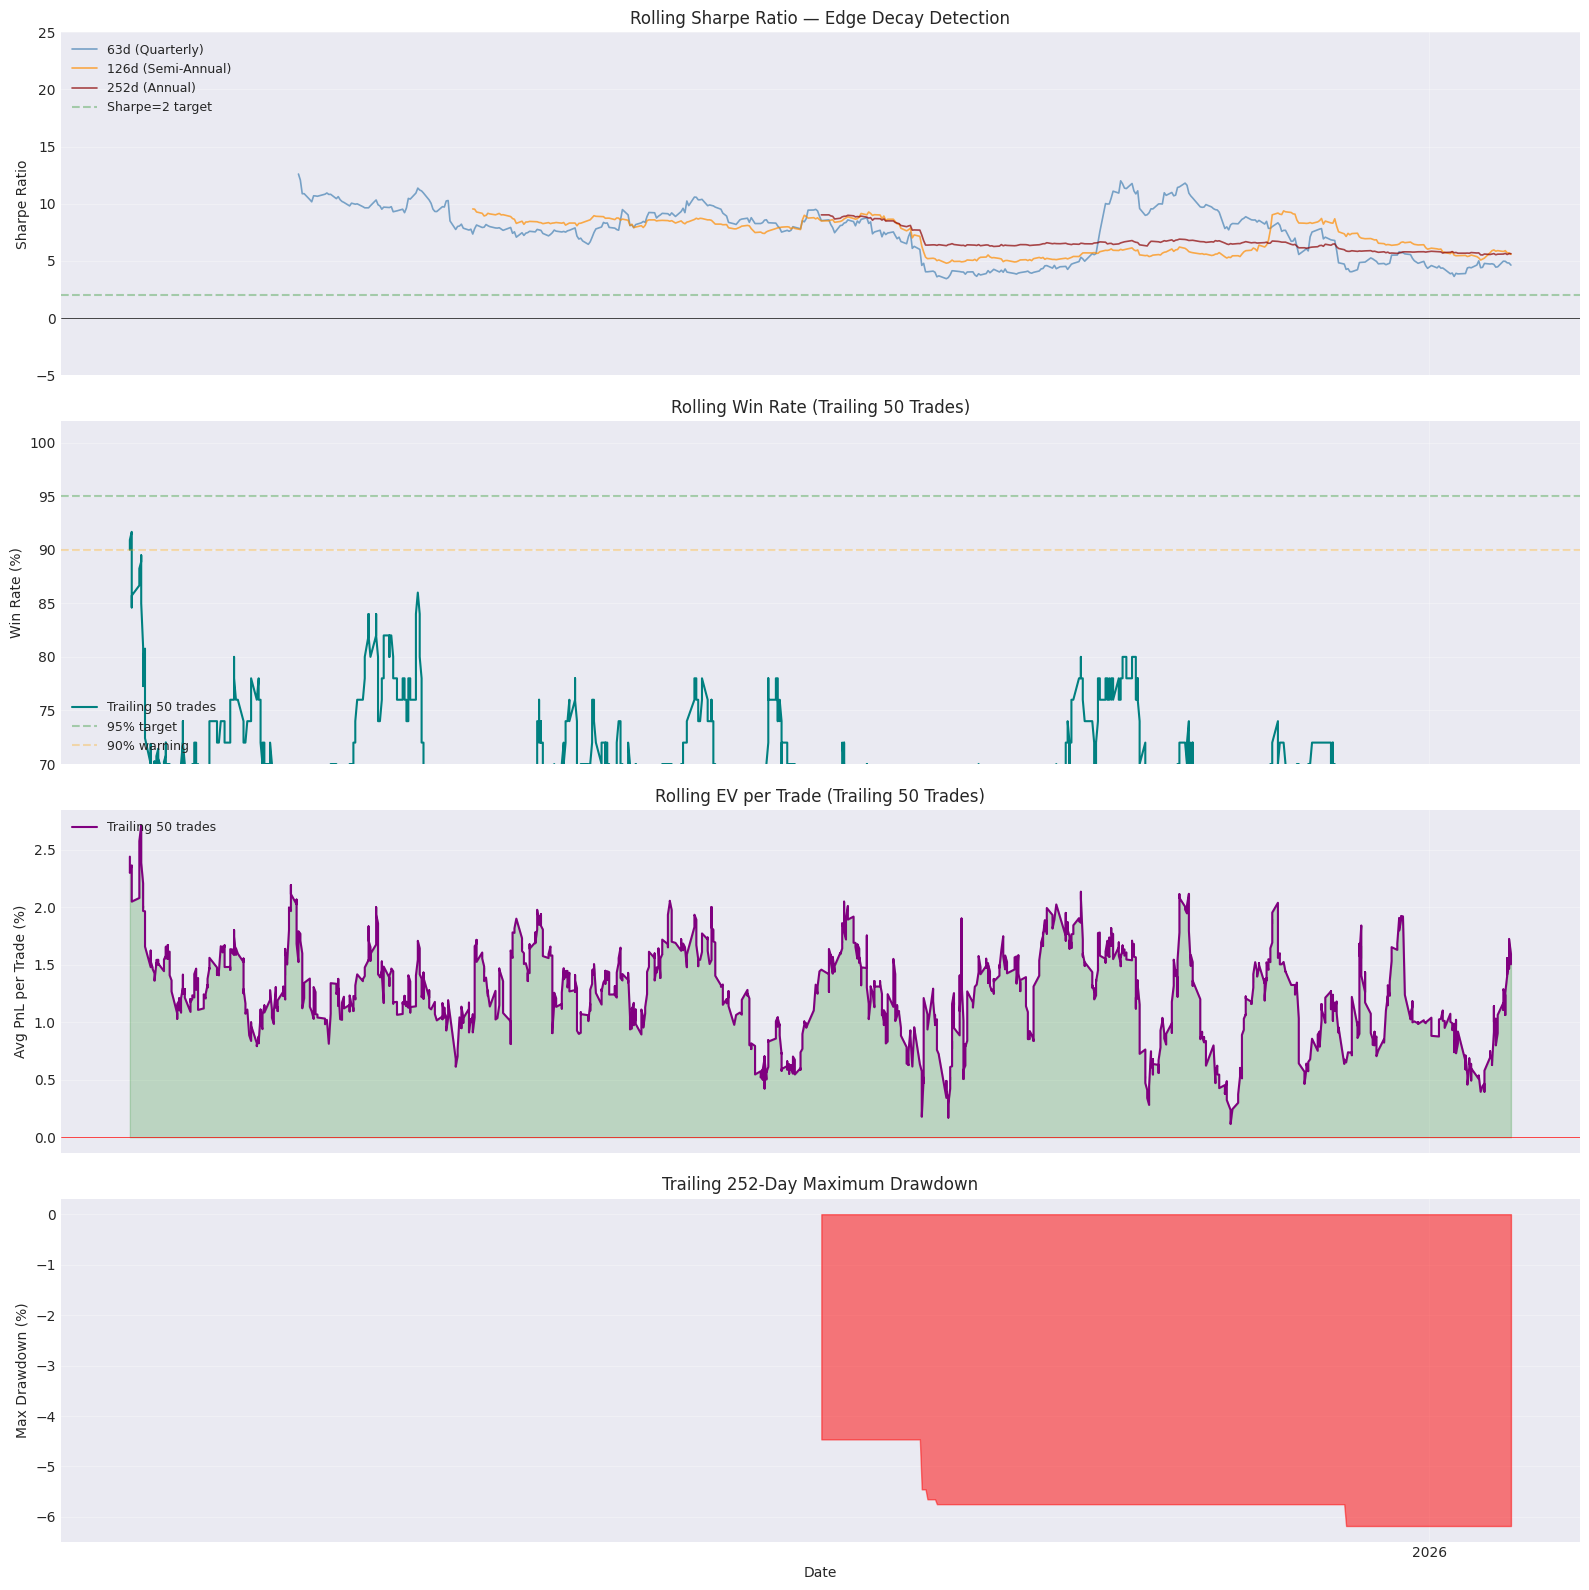

In [8]:
# 3B.2 — Rolling Analytics (Edge Decay Detection)
if _show_bt:
    analytics.rolling_analytics()
if _show_rp:
    replay_analytics.rolling_analytics()

3B.3 — TRADE-LEVEL ANALYTICS [REPLAY]

--- Win/Loss Streaks ---
  Max winning streak: 17 trades
  Avg winning streak: 3.3 trades
  Max losing streak:  7 trades
  Avg losing streak:  1.6 trades

--- Holding Period Stats ---
  Mean:   2.7 days
  Median: 1 days
  Mode:   1 days
  Max:    12 days

Saved: /workspaces/Quant/DataAnalysisExpert/3B3_trade_analytics.png


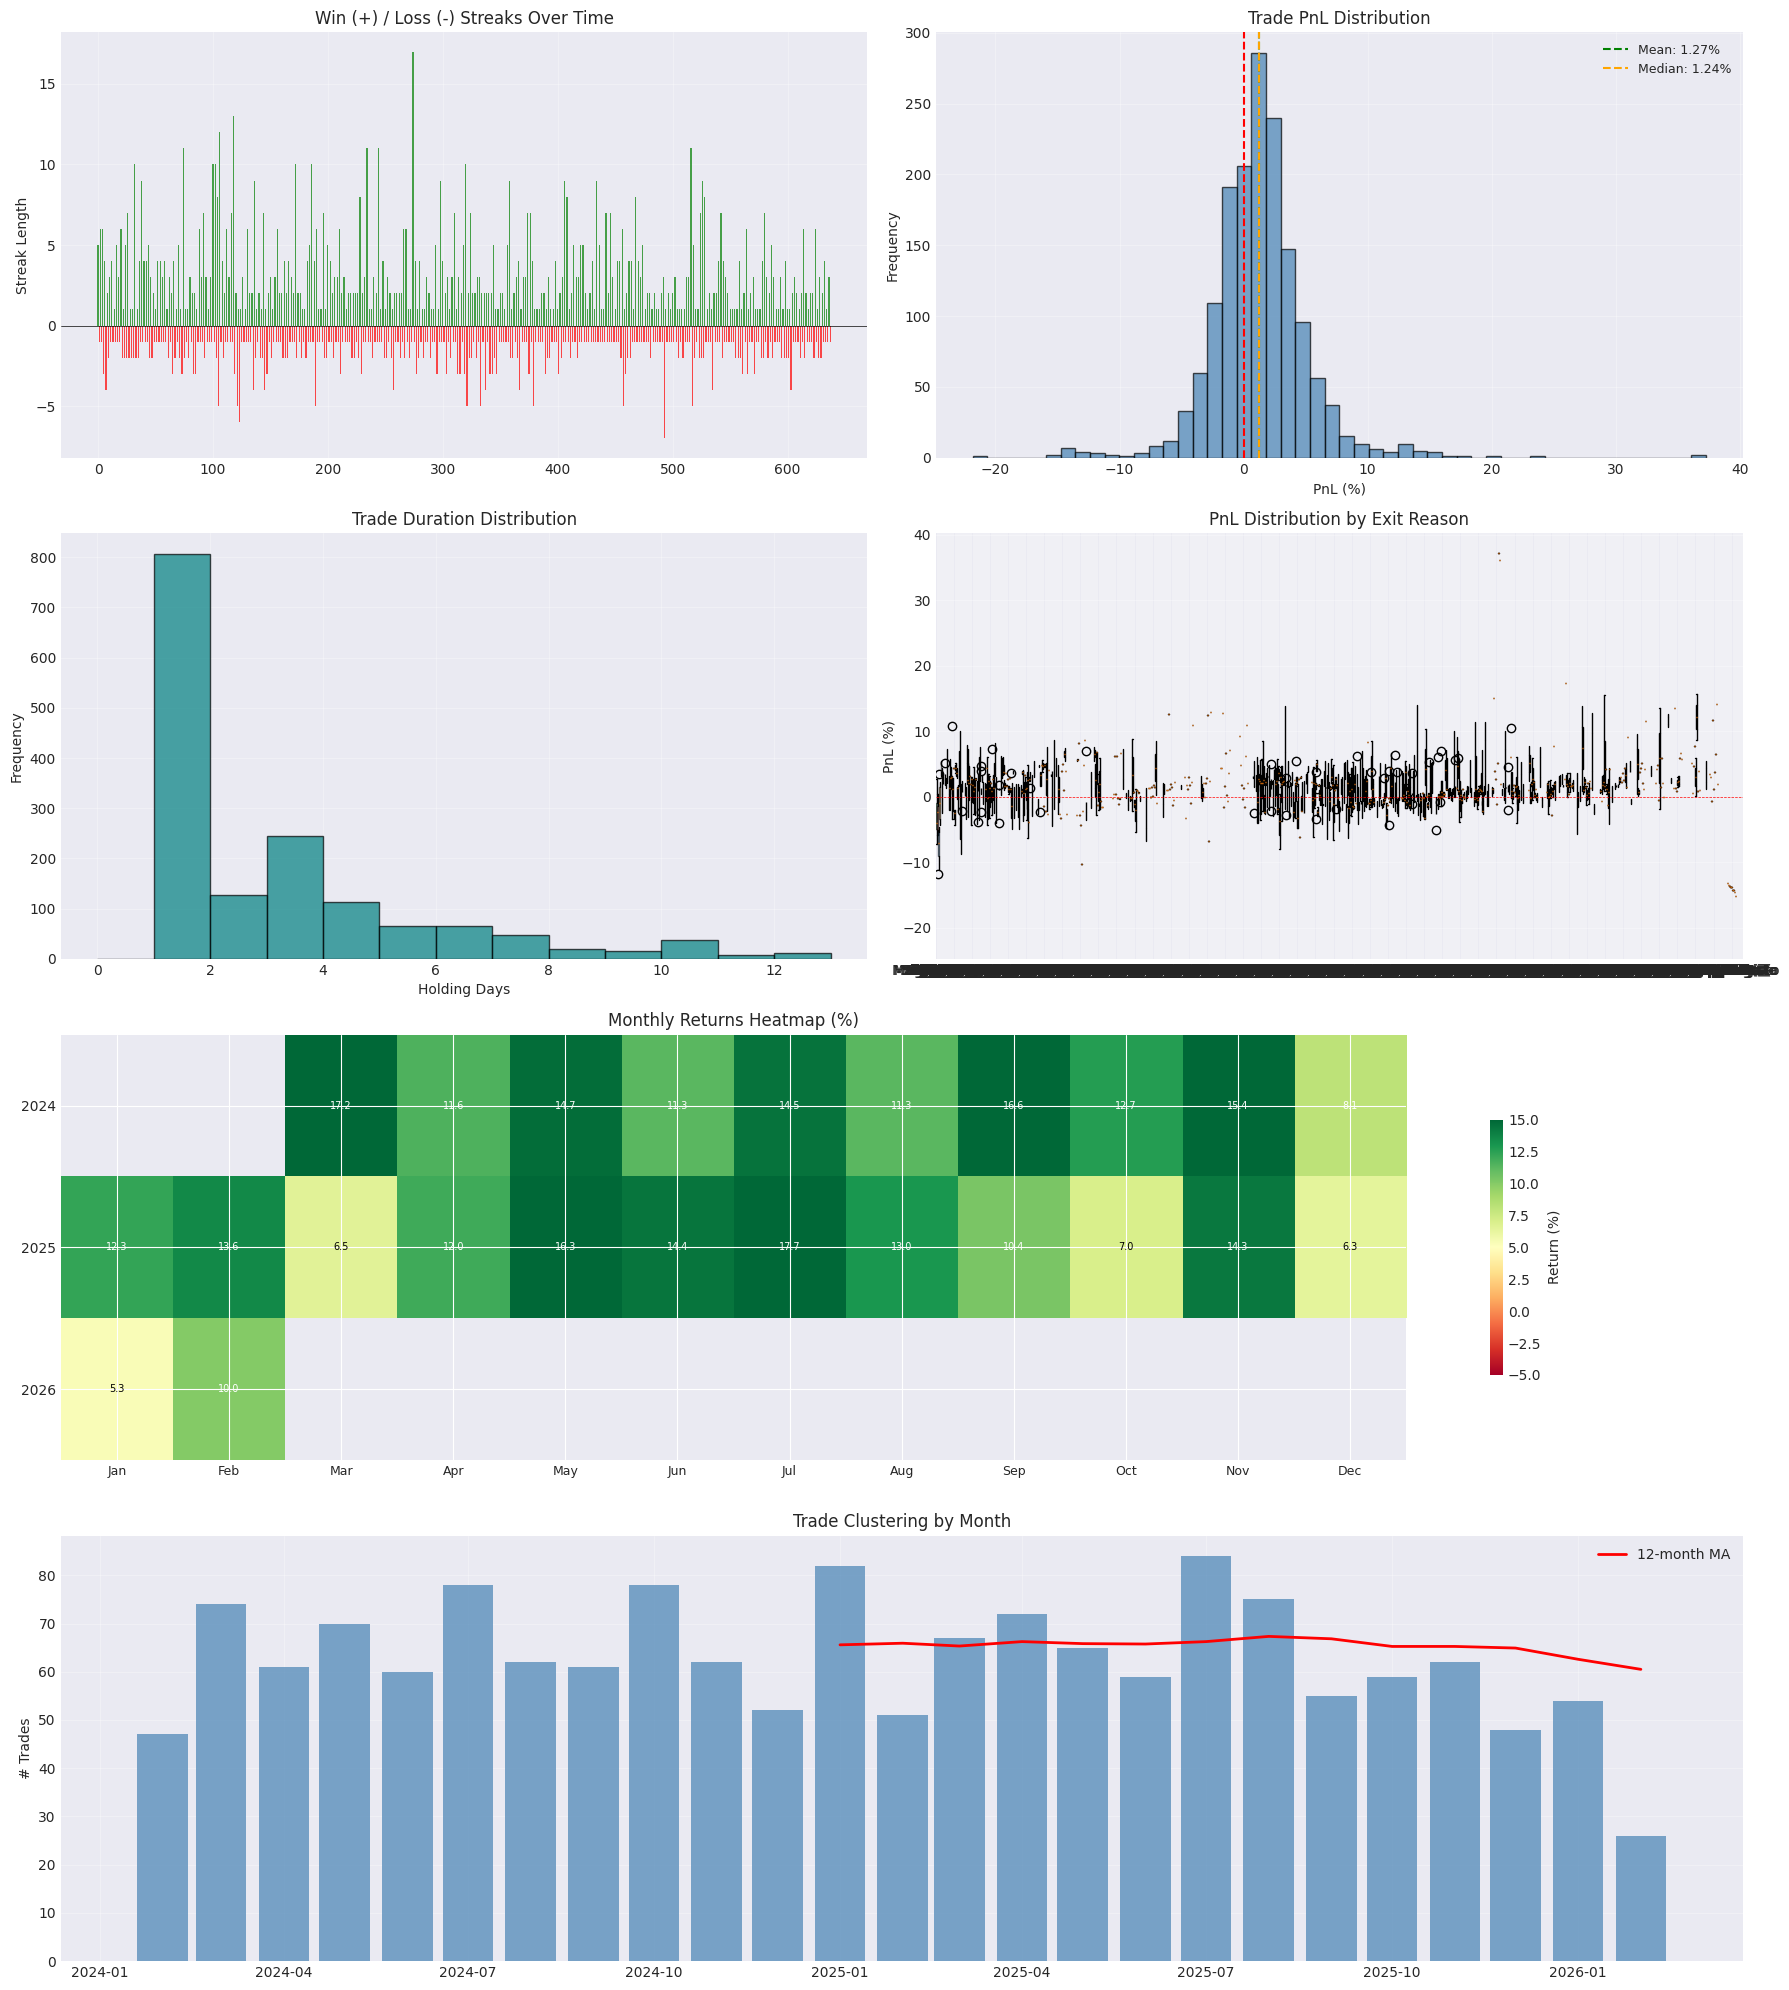

In [9]:
# 3B.3 — Trade-Level Analytics
if _show_bt:
    analytics.trade_analytics()
if _show_rp:
    replay_analytics.trade_analytics()

In [10]:
# 3B.4 — Turnover & Cost Analysis
if _show_bt:
    turnover_report = analytics.turnover_analysis()
if _show_rp:
    rp_turnover_report = replay_analytics.turnover_analysis()

3B.4 — TURNOVER & COST ANALYSIS [REPLAY]

--- Gross vs Net Returns ---
  Gross P&L (before costs):  $164,913
  Total commission+slippage: $2,588
  Net P&L (after costs):     $162,326
  Cost drag:                 1.57% of gross P&L
  Gross return:              1649.1%
  Net return:                1623.3%

--- Turnover ---
  Total traded value (round-trip): $27,121,685
  Avg portfolio value:             $61,032
  Annual turnover:                 222.63x
  Avg trades per year:             784

--- Cost Efficiency ---
  Commission/Gross ratio:  1.57%
  Avg commission per trade: $2
  Commission rate:         0.20% per side

--- Break-Even Analysis ---
  Avg gross P&L per trade:  1.67%
  Break-even one-way cost:  0.83%
  Current one-way cost:     0.20%
  Safety margin:            0.63%  (4.2x current)

--- Slippage Sensitivity ---
    Slippage   Annual Return    Total Return         Net P&L
  ---------- --------------- --------------- ---------------
       0.05%          267.3%         1242

3B.5 — ENHANCED REGIME ANALYSIS [REPLAY]

Regime                                    Period  Trades     WR  AvgPnL   Return  Sharpe   MaxDD    VaR95 Exposure
------------------------------------------------------------------------------------------------------------------------
  2024 Bull               2024-01-01→2024-12-31     705  68.8%  +1.35% +281.62%   9.04   4.46% -0.7969%  126.21%
  2025-present            2025-01-01→2026-02-28     859  65.0%  +1.20% +343.17%   5.94   6.18% -1.4732%  121.71%

Saved: /workspaces/Quant/DataAnalysisExpert/3B5_regime_analysis.png


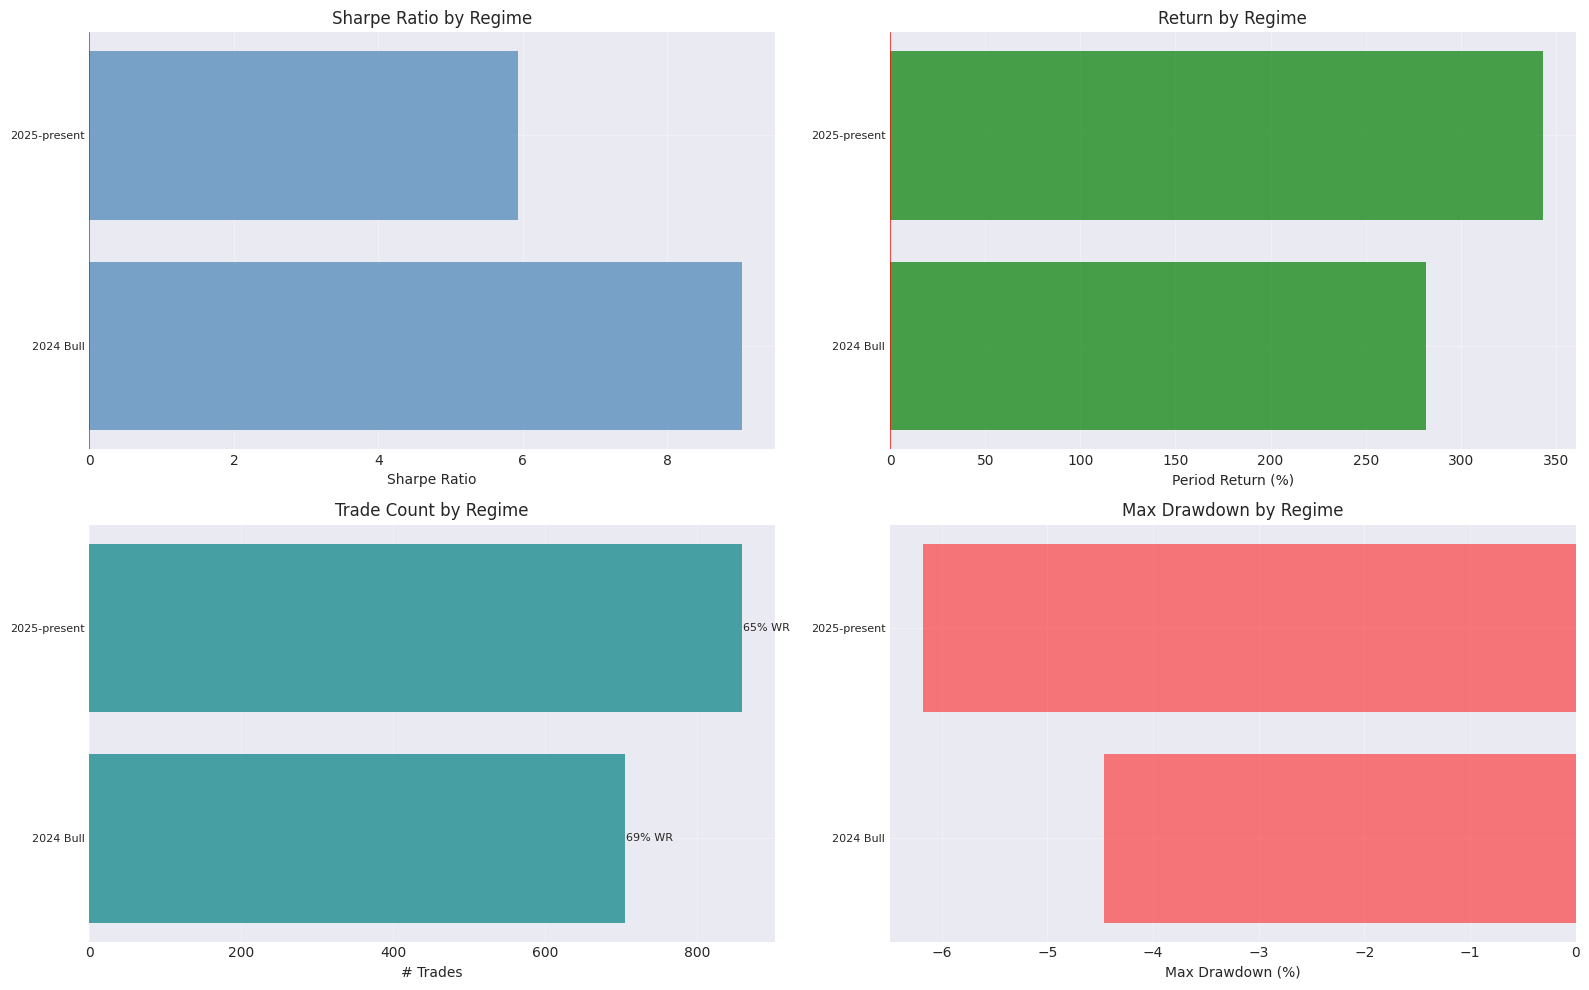


--- Key Regime Insights ---
  Best Sharpe:  2024 Bull (9.04)
  Worst Sharpe: 2025-present (5.94)
  All regimes profitable: Yes


In [11]:
# 3B.5 — Enhanced Regime Analysis
if _show_bt:
    regime_results = analytics.regime_analysis()
if _show_rp:
    rp_regime_results = replay_analytics.regime_analysis()

3B.6 — SECTOR / INDEX MEMBERSHIP ANALYSIS [REPLAY]

  Index            Symbols   Trades   Win Rate   Avg P&L%      Total P&L
  -----------------------------------------------------------------
  S&P 500               55      297      71.0%     +1.35% $      21,882
  NASDAQ-100            53      353      66.3%     +1.02% $      30,341
  Dow 30                16       73      71.2%     +1.38% $       7,664
  Russell 2000          67      528      64.8%     +1.06% $      40,974
  Other                 31      495      66.9%     +1.51% $      76,038

  Top 5 symbols by P&L:
    AFRM    $    13,437  (58 trades, 62% WR)
    ANF     $     9,166  (35 trades, 57% WR)
    CELH    $     8,148  (30 trades, 67% WR)
    RMBS    $     6,308  (22 trades, 86% WR)
    CRWD    $     5,221  (22 trades, 77% WR)

  Bottom 5 symbols by P&L:
    NFLX    $    -1,311  (4 trades, 75% WR)
    LUMN    $    -1,264  (18 trades, 61% WR)
    ZS      $    -1,050  (8 trades, 38% WR)
    GNTX    $      -903  (7 trades, 

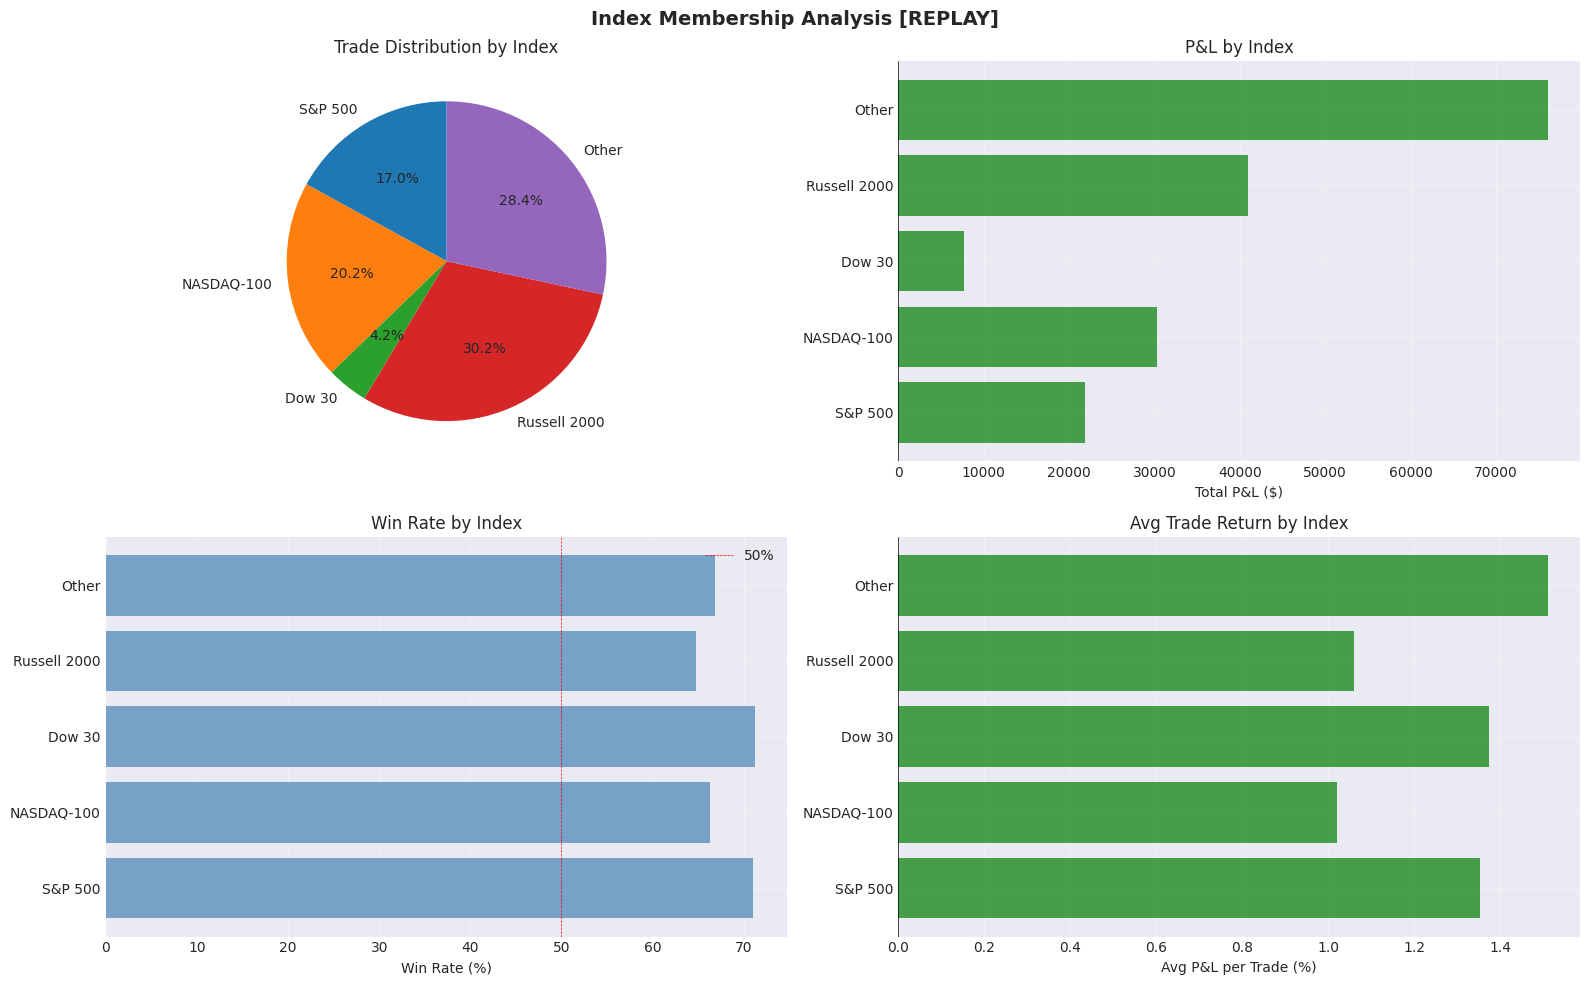

In [12]:
# 3B.6 — Sector / Index Membership Analysis
if _show_bt:
    sector_results = analytics.sector_analysis()
if _show_rp:
    rp_sector_results = replay_analytics.sector_analysis()


Saved: /workspaces/Quant/DataAnalysisExpert/3B7_slippage_sensitivity.png


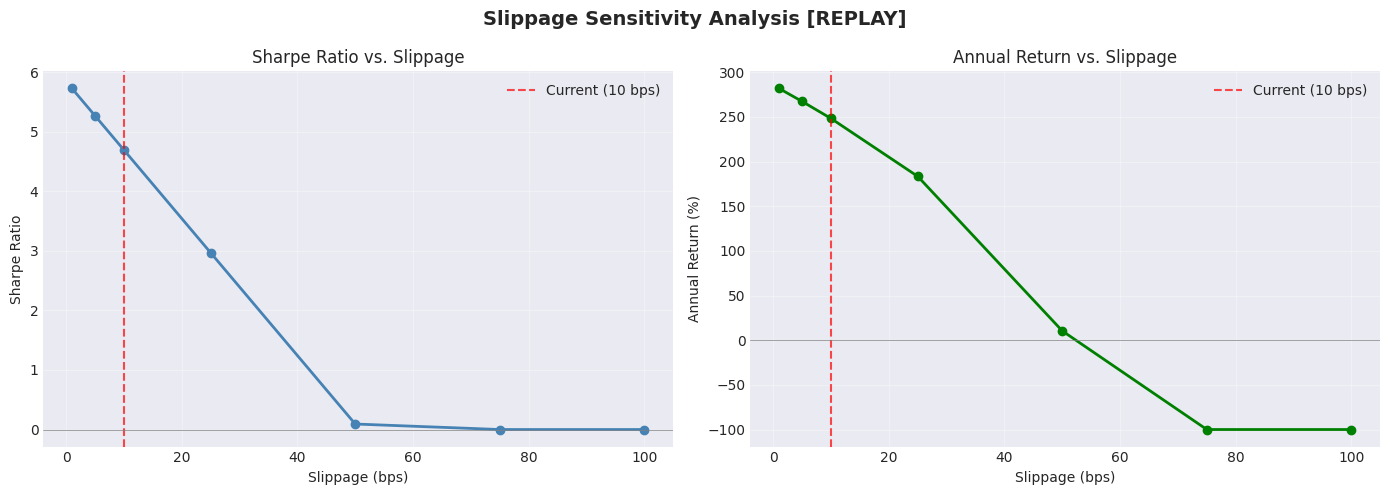

In [13]:
# 3B.7 — Slippage Sensitivity Visualization
if _show_bt:
    slip_df = analytics.slippage_sensitivity_chart()
if _show_rp:
    rp_slip_df = replay_analytics.slippage_sensitivity_chart()

3B.8 — TRADE VALIDATION [REPLAY]

  Total trades scanned: 1,564
  Flagged trades:       0

Saved: /workspaces/Quant/DataAnalysisExpert/3B8_trade_validation.png


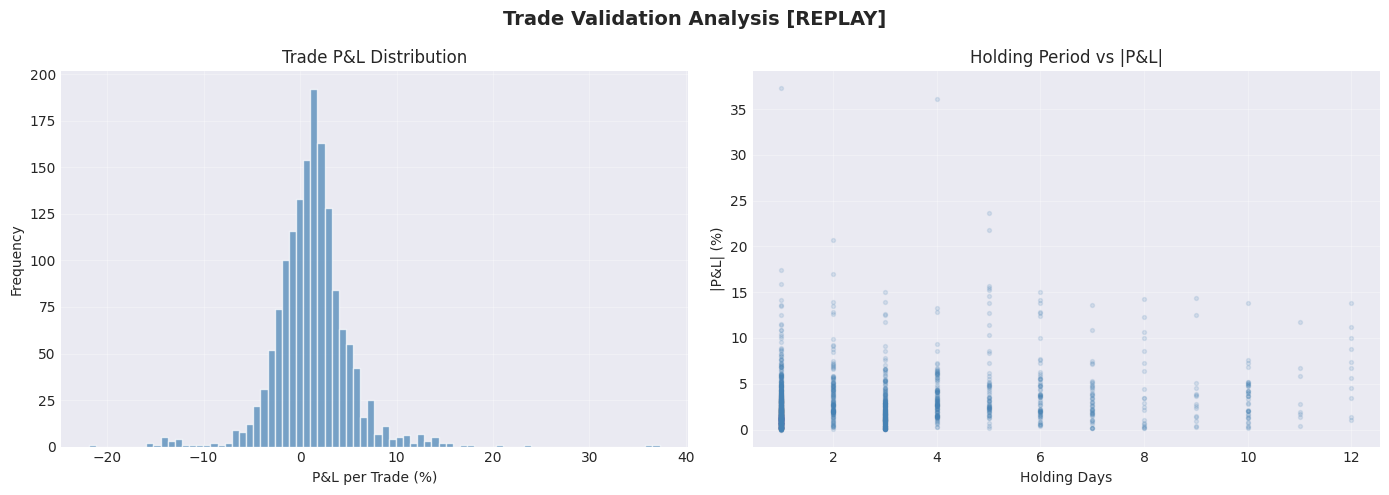

In [14]:
# 3B.8 — Trade Validation (Impossible Trade Detector)
if _show_bt:
    flagged_trades = analytics.trade_validation()
if _show_rp:
    rp_flagged_trades = replay_analytics.trade_validation()

In [15]:
# ============================================================================
# 3B.9 — DATA QUALITY AUDIT
# ============================================================================
# Checks: price jumps >20%, zero-volume days, duplicate dates, split artifacts
# Uses the already-loaded all_data dict — no redundant parquet re-reads.

import pandas as pd, numpy as np

quality_issues = []

for sym, df in all_data.items():
    if df is None or len(df) == 0:
        quality_issues.append({'symbol': sym, 'issue': 'empty_data', 'count': 1, 'detail': ''})
        continue

    # 1. Price jumps > 20% day-over-day
    if 'close' in df.columns and len(df) > 1:
        pct_change = df['close'].pct_change().abs()
        big_jumps = pct_change[pct_change > 0.20].dropna()
        if len(big_jumps) > 0:
            worst = big_jumps.idxmax()
            quality_issues.append({
                'symbol': sym, 'issue': 'price_jump_>20%',
                'count': len(big_jumps),
                'detail': f"worst={pct_change.loc[worst]:.1%} on {worst}",
            })

    # 2. Zero-volume days
    if 'volume' in df.columns:
        zero_vol = (df['volume'] == 0).sum()
        if zero_vol > 0:
            quality_issues.append({
                'symbol': sym, 'issue': 'zero_volume_days',
                'count': int(zero_vol),
                'detail': f"{zero_vol / len(df) * 100:.1f}% of days",
            })

    # 3. Duplicate dates
    if isinstance(df.index, pd.DatetimeIndex):
        dupes = df.index.duplicated().sum()
    elif 'date' in df.columns:
        dupes = df['date'].duplicated().sum()
    else:
        dupes = 0
    if dupes > 0:
        quality_issues.append({
            'symbol': sym, 'issue': 'duplicate_dates',
            'count': int(dupes), 'detail': '',
        })

    # 4. Suspicious sub-dollar prices (possible split artifact)
    if 'close' in df.columns:
        sub_dollar = (df['close'] < 1.0).sum()
        if sub_dollar > 5:
            quality_issues.append({
                'symbol': sym, 'issue': 'sub_dollar_prices',
                'count': int(sub_dollar),
                'detail': f"min=${df['close'].min():.2f}",
            })

quality_df = pd.DataFrame(quality_issues)

print("=" * 90)
print("3B.9 — DATA QUALITY AUDIT")
print("=" * 90)
print(f"\n  Symbols scanned:       {len(all_data)}")
print(f"  Symbols with issues:   {quality_df['symbol'].nunique() if len(quality_df) > 0 else 0}")
print(f"  Total flags:           {len(quality_df)}")

if len(quality_df) > 0:
    issue_summary = quality_df.groupby('issue').agg(
        symbols=('symbol', 'nunique'),
        total_count=('count', 'sum'),
    ).sort_values('symbols', ascending=False)
    print(f"\n  Issue Summary:")
    print(f"  {'Issue':<25s} {'Symbols':>8s} {'Total Count':>12s}")
    print(f"  {'-' * 45}")
    for iss, row in issue_summary.iterrows():
        print(f"  {iss:<25s} {row['symbols']:>8d} {row['total_count']:>12d}")

    # Show worst offenders
    worst = quality_df.sort_values('count', ascending=False).head(10)
    print(f"\n  Top 10 worst flags:")
    for _, r in worst.iterrows():
        print(f"    {r['symbol']:<6s} {r['issue']:<25s} count={r['count']:<5d} {r['detail']}")
else:
    print("\n  ✓ No data quality issues detected — all clean!")

3B.9 — DATA QUALITY AUDIT

  Symbols scanned:       294
  Symbols with issues:   197
  Total flags:           216

  Issue Summary:
  Issue                      Symbols  Total Count
  ---------------------------------------------
  price_jump_>20%                194          879
  zero_volume_days                17          390
  sub_dollar_prices                5         4686

  Top 10 worst flags:
    NVDA   sub_dollar_prices         count=2579  min=$0.15
    NFLX   sub_dollar_prices         count=1133  min=$0.23
    PATK   sub_dollar_prices         count=782   min=$0.07
    EXAS   sub_dollar_prices         count=126   min=$0.35
    PATK   zero_volume_days          count=123   2.4% of days
    PECO   zero_volume_days          count=87    7.0% of days
    PLAB   sub_dollar_prices         count=66    min=$0.35
    IESC   zero_volume_days          count=44    0.9% of days
    NOG    zero_volume_days          count=42    0.9% of days
    PATK   price_jump_>20%           count=41    worst

In [16]:
# ============================================================================
# 3B.10 — Backtest vs Replay Comparison
# ============================================================================
# Side-by-side analysis of backtest (vectorised) vs historical replay
# (event-driven) to validate strategy robustness under realistic execution.

from plotly.subplots import make_subplots
import numpy as np

if replay_results and 'error' not in replay_results:
    # ── Metrics Table ──
    print("=" * 70)
    print("  BACKTEST vs REPLAY COMPARISON")
    print("=" * 70)

    bt_return = results.total_return * 100
    rp_return = replay_results['total_return_pct']
    bt_sharpe = results.sharpe_ratio
    rp_sharpe = replay_results['sharpe_ratio']
    bt_dd     = results.max_drawdown * 100
    rp_dd     = replay_results['max_drawdown_pct']
    bt_wr     = results.win_rate * 100
    rp_wr     = replay_results['win_rate']
    bt_trades = results.total_trades
    rp_trades = replay_results['total_trades']
    bt_final  = results.equity_curve.iloc[-1] if len(results.equity_curve) > 0 else 0
    rp_final  = replay_results['final_equity']

    print(f"\n{'Metric':<25s} {'Backtest':>12s} {'Replay':>12s} {'Delta':>10s}")
    print("-" * 60)
    print(f"{'Total Return':<25s} {bt_return:>11.2f}% {rp_return:>11.2f}% {rp_return - bt_return:>+9.2f}%")
    print(f"{'Sharpe Ratio':<25s} {bt_sharpe:>12.2f} {rp_sharpe:>12.2f} {rp_sharpe - bt_sharpe:>+10.2f}")
    print(f"{'Max Drawdown':<25s} {bt_dd:>11.2f}% {rp_dd:>11.2f}% {rp_dd - bt_dd:>+9.2f}%")
    print(f"{'Win Rate':<25s} {bt_wr:>11.1f}% {rp_wr:>11.1f}% {rp_wr - bt_wr:>+9.1f}%")
    print(f"{'Total Trades':<25s} {bt_trades:>12d} {rp_trades:>12d} {rp_trades - bt_trades:>+10d}")
    print(f"{'Final Equity':<25s} ${bt_final:>11,.0f} ${rp_final:>11,.0f}")

    # ── 3-panel Visualization ──
    rp_eq = replay_results.get('equity_curve')
    bt_eq = results.equity_curve

    if rp_eq is not None and len(rp_eq) > 0:
        bt_eq_trim = bt_eq[bt_eq.index >= replay_start]

        if len(bt_eq_trim) > 0:
            # Normalize to base-100
            rp_norm = rp_eq / rp_eq.iloc[0] * 100
            bt_norm = bt_eq_trim / bt_eq_trim.iloc[0] * 100

            # Drawdowns
            rp_peak = rp_eq.cummax()
            rp_dd_s = (rp_eq - rp_peak) / rp_peak * 100
            bt_peak = bt_eq_trim.cummax()
            bt_dd_s = (bt_eq_trim - bt_peak) / bt_peak * 100

            # Daily returns
            rp_daily = rp_eq.pct_change().dropna() * 100
            bt_daily = bt_eq_trim.pct_change().dropna() * 100

            fig = make_subplots(
                rows=3, cols=1, shared_xaxes=True,
                row_heights=[0.45, 0.3, 0.25],
                vertical_spacing=0.06,
                subplot_titles=[
                    'Normalized Equity Curves (base=100)',
                    'Drawdown Comparison',
                    'Daily Return Distribution',
                ],
            )

            # Panel 1 — Equity overlay
            fig.add_trace(go.Scatter(
                x=bt_norm.index, y=bt_norm.values,
                mode='lines', name='Backtest',
                line=dict(color='#f0883e', width=2, dash='dot'),
            ), row=1, col=1)
            fig.add_trace(go.Scatter(
                x=rp_norm.index, y=rp_norm.values,
                mode='lines', name='Replay',
                line=dict(color='#667eea', width=2),
            ), row=1, col=1)

            # Panel 2 — Drawdowns
            fig.add_trace(go.Scatter(
                x=bt_dd_s.index, y=bt_dd_s.values,
                mode='lines', name='BT Drawdown',
                line=dict(color='#f0883e', width=1.5),
                fill='tozeroy', fillcolor='rgba(240,136,62,0.15)',
                showlegend=False,
            ), row=2, col=1)
            fig.add_trace(go.Scatter(
                x=rp_dd_s.index, y=rp_dd_s.values,
                mode='lines', name='RP Drawdown',
                line=dict(color='#667eea', width=1.5),
                fill='tozeroy', fillcolor='rgba(102,126,234,0.15)',
                showlegend=False,
            ), row=2, col=1)

            # Panel 3 — Return distributions
            fig.add_trace(go.Histogram(
                x=bt_daily.values, name='BT Returns',
                marker_color='rgba(240,136,62,0.6)',
                nbinsx=50, showlegend=False,
            ), row=3, col=1)
            fig.add_trace(go.Histogram(
                x=rp_daily.values, name='RP Returns',
                marker_color='rgba(102,126,234,0.6)',
                nbinsx=50, showlegend=False,
            ), row=3, col=1)

            fig.update_layout(
                height=800, autosize=True,
                template='plotly_dark',
                paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
                legend=dict(orientation='h', x=0, y=1.05),
                barmode='overlay',
                margin=dict(l=60, r=30, t=40, b=30),
            )
            fig.update_yaxes(title_text='Normalized Equity', row=1, col=1)
            fig.update_yaxes(title_text='Drawdown (%)', row=2, col=1)
            fig.update_yaxes(title_text='Frequency', row=3, col=1)
            fig.update_xaxes(title_text='Daily Return (%)', row=3, col=1)

            fig.show()
            plt.close('all')

            # Rolling correlation
            common_idx = rp_eq.index.intersection(bt_eq_trim.index)
            if len(common_idx) > 20:
                corr = np.corrcoef(
                    rp_eq.loc[common_idx].values,
                    bt_eq_trim.loc[common_idx].values,
                )[0, 1]
                print(f"\n  Equity curve correlation: {corr:.4f}")

    # Export replay trades
    if replay_results.get('trades_df') is not None and len(replay_results['trades_df']) > 0:
        export_path = project_root / 'data' / 'snapshots' / 'replay_trades.csv'
        replay_results['trades_df'].to_csv(export_path, index=False)
        print(f"\n📄 Trade log exported to: {export_path}")
else:
    print("⚠ Replay did not produce valid results — skipping comparison.")

# Free large replay objects after visualization
try:
    del replay_sim
except NameError:
    pass
import gc; gc.collect()

  BACKTEST vs REPLAY COMPARISON

Metric                        Backtest       Replay      Delta
------------------------------------------------------------
Total Return                110753.76%     1608.50% -109145.26%
Sharpe Ratio                      3.25         6.99      +3.74
Max Drawdown                    14.00%       -6.18%    -20.18%
Win Rate                         64.2%        66.7%      +2.5%
Total Trades                     14820         1564     -13256
Final Equity              $ 11,085,376 $    170,658



  Equity curve correlation: 0.9504

📄 Trade log exported to: /workspaces/Quant/data/snapshots/replay_trades.csv


11564

In [17]:
# ============================================================================
# PARITY TEST — Automated Backtest vs Replay Drift Detection
# ============================================================================
# Compares backtest and replay over the SAME 2-year window.
# Previous version compared full 20-yr backtest vs 2-yr replay (apples to oranges).
# Now we trim the backtest equity curve to replay_start..replay_end, recompute
# metrics for that window, and compare like-for-like.

import numpy as np

PARITY_TOLERANCE = {
    'total_return_pct': 10.0,    # Allow up to 10% abs delta
    'sharpe_ratio':      0.5,    # Allow 0.5 abs delta
    'max_drawdown_pct':  5.0,    # Allow 5% abs delta
    'win_rate_pct':      5.0,    # Allow 5% abs delta
    'trade_count_pct':  15.0,    # Allow 15% relative delta in trade count
}

if replay_results and 'error' not in replay_results:
    print("=" * 80)
    print("  PARITY TEST — Backtest vs Replay Drift Detection (same 2-yr window)")
    print("=" * 80)

    # ── Trim backtest to replay window ──
    bt_eq_full = results.equity_curve
    bt_eq_window = bt_eq_full[(bt_eq_full.index >= replay_start) & (bt_eq_full.index <= replay_end)]

    if len(bt_eq_window) > 10:
        # Backtest metrics over the same 2-yr window
        bt_return = (bt_eq_window.iloc[-1] / bt_eq_window.iloc[0] - 1) * 100
        bt_returns_window = bt_eq_window.pct_change().dropna()
        bt_sharpe = float(np.sqrt(252) * bt_returns_window.mean() / bt_returns_window.std()) if bt_returns_window.std() > 0 else 0.0
        bt_peak = bt_eq_window.cummax()
        bt_dd_s = (bt_eq_window - bt_peak) / bt_peak
        bt_dd = abs(bt_dd_s.min()) * 100

        # Backtest trades in replay window
        bt_window_trades = [
            t for t in results.trades
            if t.entry_date >= replay_start and t.exit_date <= replay_end
        ]
        bt_trades = len(bt_window_trades)
        bt_wins = sum(1 for t in bt_window_trades if t.pnl > 0)
        bt_wr = (bt_wins / bt_trades * 100) if bt_trades > 0 else 0.0

        # Replay metrics (unchanged)
        rp_return = replay_results['total_return_pct']
        rp_sharpe = replay_results['sharpe_ratio']
        rp_dd     = abs(replay_results['max_drawdown_pct'])
        rp_wr     = replay_results['win_rate']
        rp_trades = replay_results['total_trades']

        print(f"\n  Window: {replay_start.strftime('%Y-%m-%d')} → {replay_end.strftime('%Y-%m-%d')}")
        print(f"  Backtest days in window: {len(bt_eq_window)}")

        checks = [
            ('Total Return',   abs(rp_return - bt_return),       PARITY_TOLERANCE['total_return_pct'],  f"BT={bt_return:+.2f}%  RP={rp_return:+.2f}%  Δ={rp_return - bt_return:+.2f}%"),
            ('Sharpe Ratio',   abs(rp_sharpe - bt_sharpe),       PARITY_TOLERANCE['sharpe_ratio'],      f"BT={bt_sharpe:.2f}  RP={rp_sharpe:.2f}  Δ={rp_sharpe - bt_sharpe:+.2f}"),
            ('Max Drawdown',   abs(rp_dd - bt_dd),               PARITY_TOLERANCE['max_drawdown_pct'],  f"BT={bt_dd:.2f}%  RP={rp_dd:.2f}%  Δ={rp_dd - bt_dd:+.2f}%"),
            ('Win Rate',       abs(rp_wr - bt_wr),               PARITY_TOLERANCE['win_rate_pct'],       f"BT={bt_wr:.1f}%  RP={rp_wr:.1f}%  Δ={rp_wr - bt_wr:+.1f}%"),
            ('Trade Count',    abs(rp_trades - bt_trades) / max(bt_trades, 1) * 100,
                               PARITY_TOLERANCE['trade_count_pct'], f"BT={bt_trades}  RP={rp_trades}  Δ={rp_trades - bt_trades:+d} ({(rp_trades - bt_trades) / max(bt_trades,1) * 100:+.1f}%)"),
        ]

        print(f"\n  {'Metric':<18s} {'Details':>60s} {'Tol':>8s} {'Status':>8s}")
        print(f"  {'-' * 98}")

        n_pass = 0
        for name, delta, tol, delta_str in checks:
            status = '✓ PASS' if delta <= tol else '✗ FAIL'
            if delta <= tol:
                n_pass += 1
            print(f"  {name:<18s} {delta_str:>60s} {f'±{tol:.1f}':>8s} {status:>8s}")

        print(f"\n  Result: {n_pass}/{len(checks)} checks passed", end='')
        if n_pass == len(checks):
            print(" — Replay is in parity with backtest ✓")
        else:
            print(" — DRIFT DETECTED. Investigate divergent metrics.")
            print("  Note: Some drift is expected — replay uses Option-D order flow")
            print("        (market entry → GTC stop) while backtest uses flat slippage.")
    else:
        print(f"\n  ⚠ Insufficient backtest data in replay window ({len(bt_eq_window)} points)")

    # Equity correlation (normalized to same start)
    if replay_results.get('equity_curve') is not None:
        rp_eq = replay_results['equity_curve']
        bt_eq = results.equity_curve
        bt_eq_trim = bt_eq[(bt_eq.index >= replay_start) & (bt_eq.index <= replay_end)]
        common_index = rp_eq.index.intersection(bt_eq_trim.index)
        if len(common_index) > 10:
            # Normalize both to start at 1.0 for fair correlation
            rp_norm = rp_eq.loc[common_index] / rp_eq.loc[common_index].iloc[0]
            bt_norm = bt_eq_trim.loc[common_index] / bt_eq_trim.loc[common_index].iloc[0]
            corr = np.corrcoef(rp_norm.values, bt_norm.values)[0, 1]
            print(f"\n  Equity curve correlation (normalized): {corr:.4f}")
else:
    print("⚠ Replay results not available — skipping parity test.")

  PARITY TEST — Backtest vs Replay Drift Detection (same 2-yr window)

  Window: 2024-02-13 → 2026-02-13
  Backtest days in window: 503

  Metric                                                                  Details      Tol   Status
  --------------------------------------------------------------------------------------------------
  Total Return                              BT=+18.27%  RP=+1608.50%  Δ=+1590.23%    ±10.0   ✗ FAIL
  Sharpe Ratio                                          BT=8.26  RP=6.99  Δ=-1.27     ±0.5   ✗ FAIL
  Max Drawdown                                       BT=0.33%  RP=6.18%  Δ=+5.85%     ±5.0   ✗ FAIL
  Win Rate                                            BT=65.8%  RP=66.7%  Δ=+0.9%     ±5.0   ✓ PASS
  Trade Count                                   BT=1784  RP=1564  Δ=-220 (-12.3%)    ±15.0   ✓ PASS

  Result: 2/5 checks passed — DRIFT DETECTED. Investigate divergent metrics.
  Note: Some drift is expected — replay uses Option-D order flow
        (market ent